In [15]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# 1. Load MBPP and convert to pandas
ds = load_dataset("mbpp", split="train")
df = ds.to_pandas()


In [16]:
# 2. Inspect schema
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

Shape: (374, 6)
Columns: ['task_id', 'text', 'code', 'test_list', 'test_setup_code', 'challenge_test_list']


,task_id,text,code,test_list,test_setup_code,challenge_test_list
0,601,Write a function to find the longest chain whi...,"class Pair(object): \r\n\tdef __init__(self, a...","[assert max_chain_length([Pair(5, 24), Pair(15...",,[]
1,602,Write a python function to find the first repe...,"def first_repeated_char(str1):\r\n for index,...","[assert first_repeated_char(""abcabc"") == ""a"", ...",,[]
2,603,Write a function to get a lucid number smaller...,def get_ludic(n):\r\n\tludics = []\r\n\tfor i ...,"[assert get_ludic(10) == [1, 2, 3, 5, 7], asse...",,[]
3,604,Write a function to reverse words in a given s...,def reverse_words(s):\r\n return ' '.jo...,"[assert reverse_words(""python program"")==(""pro...",,[]
4,605,Write a function to check if the given integer...,def prime_num(num):\r\n if num >=1:\r\n for...,"[assert prime_num(13)==True, assert prime_num(...",,[]


In [17]:
# 3. Prompt length distribution (chars)
df["prompt_len_chars"] = df["text"].str.len()
print(df["prompt_len_chars"].describe())



count    374.000000
mean      78.430481
std       21.132525
min       38.000000
25%       64.000000
50%       77.500000
75%       90.000000
max      249.000000
Name: prompt_len_chars, dtype: float64


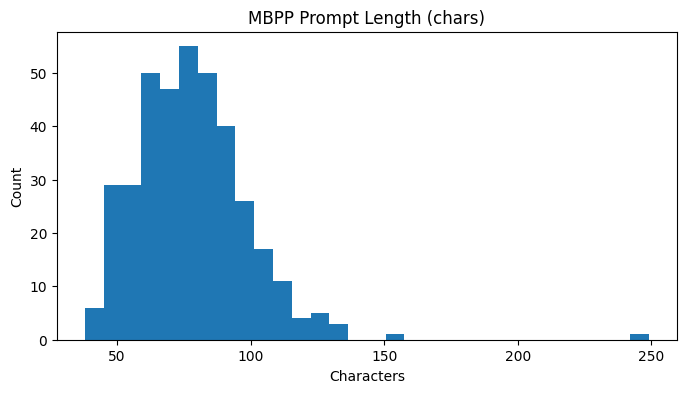

In [18]:
plt.figure(figsize=(8,4))
plt.hist(df["prompt_len_chars"], bins=30)
plt.title("MBPP Prompt Length (chars)")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.show()


In [20]:
# 4. Number of test cases per task
df["n_tests"] = df["test_list"].apply(len)
test_counts = df["n_tests"].value_counts().sort_index()
print(test_counts)

n_tests
3    374
Name: count, dtype: int64


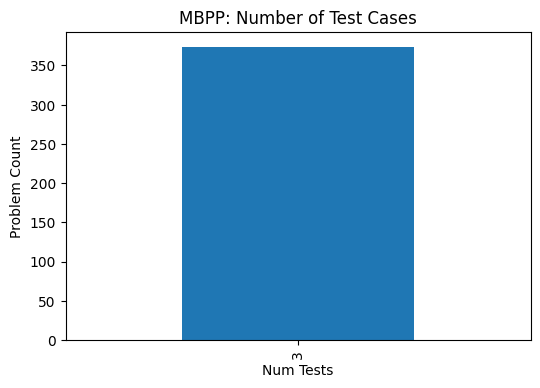

In [21]:
plt.figure(figsize=(6,4))
test_counts.plot.bar()
plt.title("MBPP: Number of Test Cases")
plt.xlabel("Num Tests")
plt.ylabel("Problem Count")
plt.show()

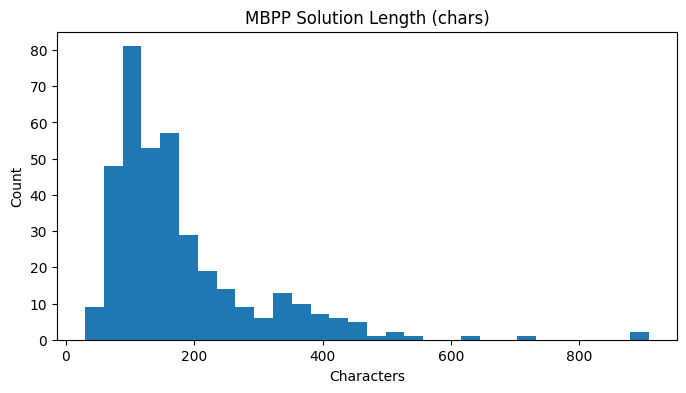

In [24]:

plt.figure(figsize=(8,4))
plt.hist(df["code_len_chars"], bins=30)
plt.title("MBPP Solution Length (chars)")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.show()

In [26]:

# 6. Category‐tagging into 9 code‐task buckets
def tag_category(text: str, code: str) -> str:
    txt = (text + " " + code).lower()
    if re.search(r"\blists?\b|append\(", txt):
        return "lists"
    if re.search(r"\bimport math\b|\bmath\b|[\d]+\s*[\+\-\*/]\s*[\d]+", txt):
        return "math"
    if re.search(r"['\"].+?['\"]", txt):
        return "strings"
    if re.search(r"\bparse\b|\bsplit\(|replace\(", txt):
        return "string_parsing"
    if re.search(r"\bfor\s+\w+\s+in\s+range\b.*\bfor\b", txt):
        return "nested_loops"
    if re.search(r"\bsorted\(|\.sort\(|\bsort\b", txt):
        return "sorting"
    if re.search(r"\bencode\b|\bdecode\b", txt):
        return "encoding_decoding"
    if re.search(r"\bdict\b|\{[^}]+:[^}]+\}", txt):
        return "dictionaries"
    return "problem_solving"

df["category"] = df.apply(lambda r: tag_category(r["text"], r["code"]), axis=1)
cat_counts = df["category"].value_counts().sort_index()
print(cat_counts)

category
dictionaries         4
lists              108
math                28
nested_loops         4
problem_solving    153
sorting             18
strings             59
Name: count, dtype: int64


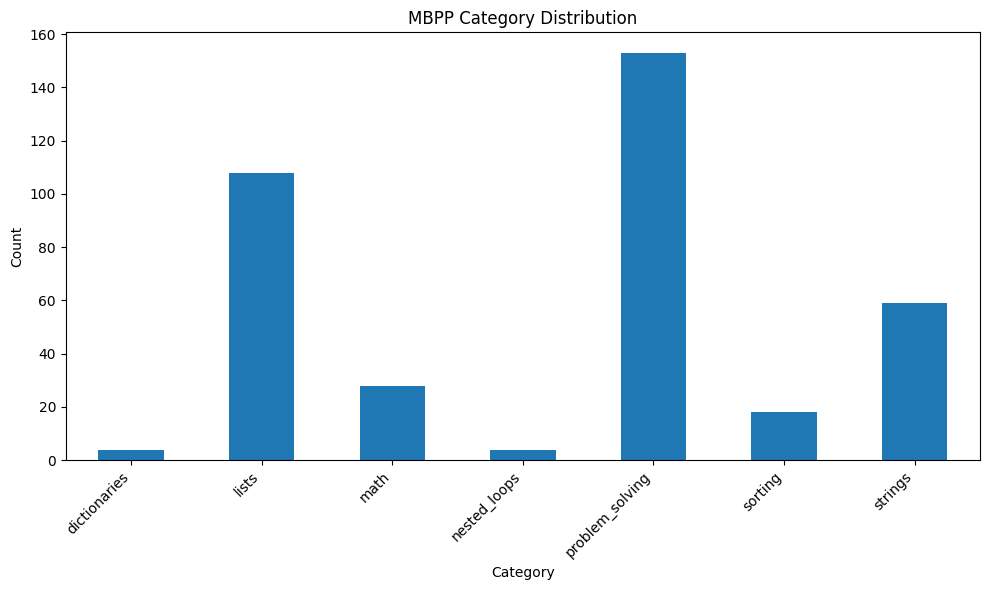

In [27]:
plt.figure(figsize=(10,6))
cat_counts.plot.bar()
plt.title("MBPP Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()